# Grad-CAM Explainability for Stroke CT Image Classification
***
In this notebook, we use Gradient-weighted Class Activation Mapping (Grad-CAM) to visualize the regions of brain CT images that influenced the ResNet50 model's predictions.

Grad-CAM enhances the interpretability of deep learning models by highlighting the most important image regions used during the classification process. This is particularly valuable in medical imaging applications, where understanding the model's decision-making process can improve transparency and increase trust in AI-assisted diagnosis.

# Import Libraries
***

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random


from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load Model
***

In [3]:
model = load_model("/kaggle/input/models/moazahmedhassanein/best-resnet50-finetuned/keras/default/1/best_resnet50_finetuned.keras")
model.summary()

2026-07-09 17:26:21.186661: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,062,469 (206.23 MB)

 Trainable params: 14,974,977 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 29,949,956 (114.25 MB)

In [4]:
# Check Layers Name
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 input_layer_2
1 resnet50
2 global_average_pooling2d
3 dense
4 dropout
5 dense_1


In [5]:
resnet_model = model.get_layer("resnet50")

print("Number of layers:", len(resnet_model.layers))

for i, layer in enumerate(resnet_model.layers[-15:]):
    print(i, layer.name)

Number of layers: 175
0 conv5_block2_2_relu
1 conv5_block2_3_conv
2 conv5_block2_3_bn
3 conv5_block2_add
4 conv5_block2_out
5 conv5_block3_1_conv
6 conv5_block3_1_bn
7 conv5_block3_1_relu
8 conv5_block3_2_conv
9 conv5_block3_2_bn
10 conv5_block3_2_relu
11 conv5_block3_3_conv
12 conv5_block3_3_bn
13 conv5_block3_add
14 conv5_block3_out


In [57]:
test_dir = "/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Test"

stroke_dir = os.path.join(test_dir, "Stroke")
normal_dir = os.path.join(test_dir, "Normal")

# Choose Random Image
img_path = random.choice(os.listdir(stroke_dir))
img_path = os.path.join(stroke_dir, img_path)

print(img_path)

/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Test/Stroke/94 (31).jpg


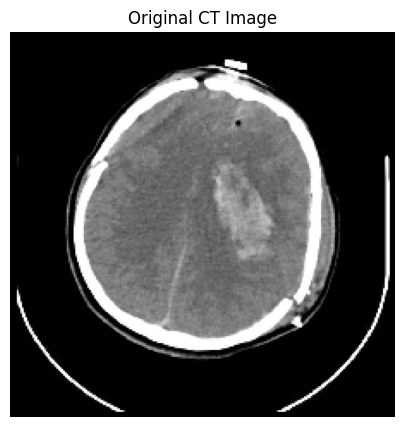

In [58]:
img = image.load_img(img_path, target_size=(224, 224))

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Original CT Image")
plt.show()

# Image Preparation for Prediction
***
Before generating the Grad-CAM visualization, the selected CT image must be prepared in the same way as the images used during model training.

The image is resized to **224 × 224 pixels**, converted into a NumPy array, and an additional batch dimension is added to match the expected input shape of the ResNet50 model. Finally, the `preprocess_input()` function is applied to normalize the image according to the preprocessing requirements of the pre-trained ResNet50 network.

Applying the same preprocessing pipeline during both training and inference ensures consistent model behavior and reliable predictions.

In [59]:
# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Apply ResNet50 preprocessing
img_array = preprocess_input(img_array)

print("Input Shape:", img_array.shape)

Input Shape: (1, 224, 224, 3)


# Model Prediction
***
After preprocessing, the image is passed to the fine-tuned ResNet50 model to obtain a prediction score.

Since the model performs **binary classification**, it outputs a probability between **0 and 1**. A threshold of **0.5** is used to determine the predicted class:

- **Score ≥ 0.5:** Stroke
- **Score < 0.5:** Normal

This prediction will later be explained using Grad-CAM to visualize the image regions that contributed most to the model's decision.

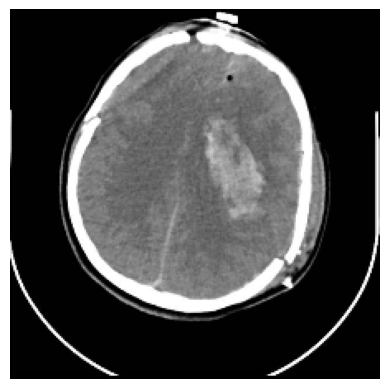

In [60]:
img = cv2.imread(img_path)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

x,y,w,h = cv2.boundingRect(thresh)

cropped = img[y:y+h, x:x+w]

cropped = cv2.resize(cropped, (224,224))

plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [61]:
prediction = model.predict(img_array)[0][0]

print(f"Prediction Score: {prediction:.4f}")

if prediction >= 0.5:
    print("Predicted Class: Stroke")
else:
    print("Predicted Class: Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Prediction Score: 0.9892
Predicted Class: Stroke


# Grad-CAM Heatmap Generation
***

## Building the Grad-CAM Model

To generate the Grad-CAM visualization, an auxiliary model is created from the **already-loaded, fine-tuned model** — no new ResNet50 and no ImageNet weights are involved.

This auxiliary model outputs the feature maps from the last convolutional layer (`conv5_block3_out`) of the `resnet50` backbone.

**Keras 3 note:** the classification head (`GlobalAveragePooling2D` → `Dense` → `Dropout` → `Dense`) is then re-applied *inside* a `GradientTape` by calling the loaded model's own head layers directly on those feature maps, instead of pulling `model.output` into the same auxiliary model. Mixing an inner submodel's intermediate output with the outer model's final output inside one `tf.keras.Model(...)` call is not supported in Keras 3's functional-graph construction and raises a `KeyError` when called — building the feature-extractor from `base_model.input`/`base_model` output only avoids this, while still using the exact same fine-tuned layers/weights for the head.

Using TensorFlow's automatic differentiation (`GradientTape`), the gradients of the predicted class are computed with respect to these feature maps. These gradients indicate the importance of each spatial location, allowing us to generate a class activation heatmap.

In [ ]:
# Backbone (already fine-tuned — reused as-is, not rebuilt)
base_model = model.get_layer("resnet50")

# Last convolution layer
last_conv_layer = base_model.get_layer("conv5_block3_out")

# Build Grad-CAM feature-extraction model.

grad_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)

## Generating the Grad-CAM Heatmap

The Grad-CAM heatmap is generated by computing the gradients of the predicted class with respect to the feature maps extracted from the last convolutional layer.

These gradients are globally averaged to obtain the importance of each feature map. The weighted combination of these feature maps produces a localization heatmap that highlights the regions of the CT image most responsible for the model's prediction.

The resulting heatmap is normalized to the range [0, 1] for visualization.

In [63]:
gap_layer = model.layers[2]
dense_layer = model.layers[3]
dropout_layer = model.layers[4]
output_layer = model.layers[5]

def make_gradcam_heatmap(img_array):

    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:

        # Forward through the ResNet50 backbone only, up to the last conv layer
        conv_outputs = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)

        # Continue through the SAME classification head used by the loaded model
        x = gap_layer(conv_outputs)
        x = dense_layer(x)
        x = dropout_layer(x, training=False)
        predictions = output_layer(x)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy()

## Visualizing the Heatmap

The generated Grad-CAM heatmap provides a visual representation of the regions that contributed most to the model's prediction.

Warmer colors (red/yellow) indicate regions with higher importance, while cooler colors (blue) represent areas that had little influence on the classification decision.

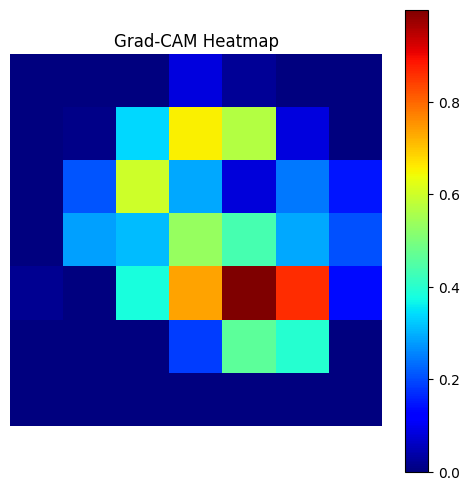

In [64]:
heatmap = make_gradcam_heatmap(img_array)

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

## Overlaying the Heatmap on the Original Image

To improve interpretability, the Grad-CAM heatmap is superimposed onto the original CT image.

This visualization highlights the regions that contributed most to the model's prediction while preserving the anatomical structures of the original scan. Warmer colors indicate stronger activation and greater influence on the classification decision.

In [65]:
# Load original image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

# Resize heatmap
heatmap_resized = cv2.resize(heatmap, (224, 224))

# Smooth the heatmap
heatmap_resized = cv2.GaussianBlur(heatmap_resized, (11, 11), 0)

# Normalize
heatmap_resized = heatmap_resized / np.max(heatmap_resized)

# Remove weak activations
threshold = 0.4
heatmap_resized[heatmap_resized < threshold] = 0

# Convert to uint8
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# Apply JET colormap
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Overlay
superimposed = cv2.addWeighted(
    img,
    0.7,
    heatmap_color,
    0.5,
    0
)

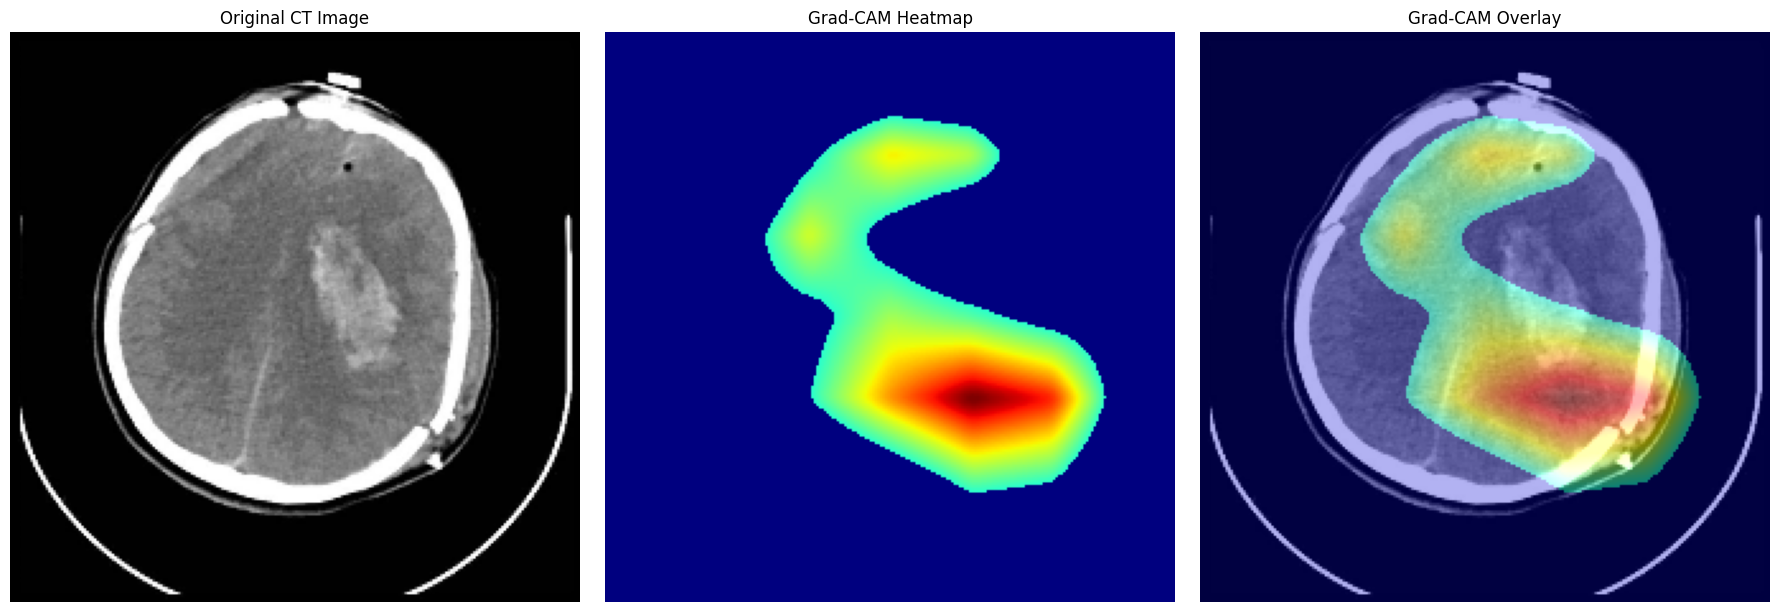

In [66]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img)
ax[0].set_title("Original CT Image")
ax[0].axis("off")

ax[1].imshow(heatmap_resized, cmap="jet")
ax[1].set_title("Grad-CAM Heatmap")
ax[1].axis("off")

ax[2].imshow(superimposed)
ax[2].set_title("Grad-CAM Overlay")
ax[2].axis("off")

plt.tight_layout()
plt.show()

# Conclusion
***
The Grad-CAM visualization was used to interpret the model's predictions by highlighting the image regions that contributed most to the classification decision. The results showed that while the model was able to focus on parts of the head, it also relied on surrounding structures such as skull boundaries and image edges in several cases, rather than concentrating solely on the brain tissue.

This observation indicates that, despite achieving strong classification performance, there is still room for improving the model's interpretability. Future work may include applying more targeted preprocessing techniques (e.g., brain region extraction or background removal), improving data quality, or exploring more advanced explainability methods such as Grad-CAM++ or Score-CAM to encourage the model to focus on clinically relevant brain regions.